# **Lab 02:** Creating your own CNN with PyTorch

### **General Instructions**

- In this lab, you'll create your own CNN in order to surpass an accuracy of 70% on CIFAR-10.

### **System Diagram Requirement**

You must include a **diagram of your system pipeline** showing the CNN architecture.

This diagram is **required** to understand your model logic.

You can draw it digitally, use any Pyhton library, or by hand and include an image.

If your diagram was created assisted by GenAI, also include the `promt` used in the next block. If the generated system diagram is not clear or you cannot interpret it, adjust the prompt as needed or draw it by hand.

*If you used GenAI, write your prompt here..*

### **Load the CIFAR-10 dataset**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [6]:
# Load the CIFAR-10 dataset here
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Número de imágenes en train: 50000
Número de imágenes en test:  10000
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


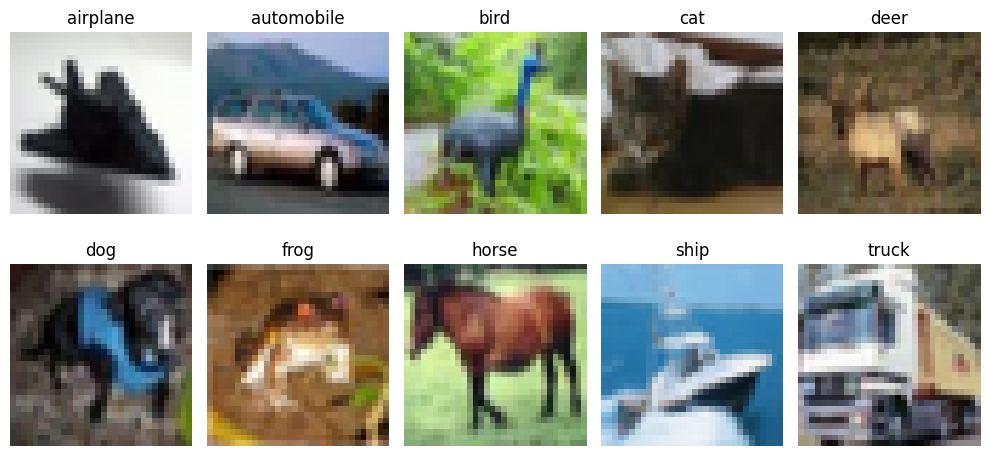

In [7]:
# Comprobar tamaños de los conjuntos y visualizar una imagen por clase
print(f"Número de imágenes en train: {len(train_dataset)}")
print(f"Número de imágenes en test:  {len(test_dataset)}")

# CIFAR-10 tiene 10 clases
class_names = train_dataset.classes  # nombres de las clases
print("Clases:", class_names)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

# Mostrar una imagen representativa por cada clase
shown = {i: False for i in range(len(class_names))}
for img, label in train_dataset:
    idx = int(label)
    if not shown[idx]:
        # img viene como tensor [C, H, W] en rango [0,1]
        img_np = img.permute(1, 2, 0).numpy()
        axes[idx].imshow(img_np)
        axes[idx].set_title(class_names[idx])
        axes[idx].axis("off")
        shown[idx] = True
        # Cuando ya tenemos una imagen de cada clase, paramos
        if all(shown.values()):
            break

plt.tight_layout()
plt.show()

### **Create your CNN with PyTorch and train it on the CIFAR-10 dataset**

In [12]:
# Create your own CNN using PyTorch and train it on the CIFAR-10 dataset

class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        # Bloque 1: Más filtros y BatchNorm
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1) 
        self.bn1 = nn.BatchNorm2d(32)
        
        # Bloque 2: Capa más profunda
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Bloque 3: Capa extra para captar más detalles
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout para regularización
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()

        # Cálculo de dimensiones: 
        # 32x32 -> pool -> 16x16 -> pool -> 8x8 -> pool -> 4x4
        self.fc1 = nn.Linear(64 * 4 * 4, 256) 
        self.fc2 = nn.Linear(256, 10)
        
    def forward(self, x):
        # Bloque 1
        x = self.pool(self.relu(self.bn1(self.conv1(x)))) # Result: 16x16
        # Bloque 2
        x = self.pool(self.relu(self.bn2(self.conv2(x)))) # Result: 8x8
        # Bloque 3
        x = self.pool(self.relu(self.bn3(self.conv3(x)))) # Result: 4x4
        
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 1.2573
Epoch 2/5, Loss: 0.9044
Epoch 3/5, Loss: 0.7808
Epoch 4/5, Loss: 0.7055
Epoch 5/5, Loss: 0.6390


There were 4 important changes:

1. Batch Normalization: Normalizes activities in the intermediate layers, and allows to use learning rates a bit higher without the model crashing, making the training more stable and faster.
2. More filters and layers: There was added a third convolutional layer, so the network has a more abstract view of the image. Also, the filters went from 16/32 to 32/64/64, allowing to extract more characteristics and more complex shapes.
3. Dropout: By disabling randomly neurons in the training, the network doesn't memorize data nor noise from the training, decreasing overfitting.
4. Fully Connected Layer: Increasing the hidden layer from 128 to 256 neurons, there's more space for the final classificator to process more complex patterns.

### **Evaluate the accuracy of your CNN (must be >= 70%)**

In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cnn_acc = accuracy_score(all_labels, all_preds)
print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.75


### **System Diagram**

Insert your system diagram (CNN architecture) below (image or drawing). It must clearly show:

- Number of convolutional layers  
- Kernel size(s)
- Pooling layers (if any)  
- etc..  

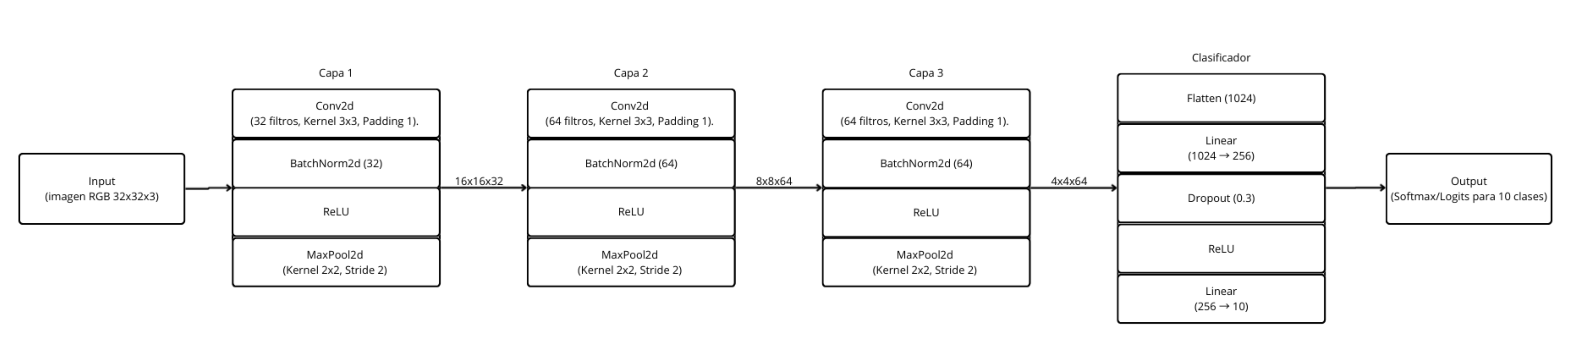

In [6]:
# Insert or display your system diagram image here

img = plt.imread(r"C:\Users\Cedel\Downloads\system_diagram.png")

plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis('off')
plt.show()

### **Written Analysis Questions**

**1. Why increasing depth could improve performance.**

More layers mean the model can represent more sophisticated mappings between the pixels and the labels. Early layers detect simple edges and textures, while deeper layers combine those into complex shapes and objects.

**2. Under what conditions deeper networks may hurt performance.**

An important example is the Overfitting, if the model is too complex for the amount of data, it memorizes noise instead of learning patterns.

**3. How could dropout, batch normalization, or data augmentation help?**

- Dropout: Acts as a regularizer by randomly "disabling" neurons during training, preventing the network from becoming overly reliant on specific paths (reduces overfitting).
- Batch Normalization: Normalizes the inputs to each layer, which speeds up training, allows for higher learning rates, and provides a slight regularization effect.
- Data Augmentation: Artificially increases the dataset size by flipping, rotating, or cropping images. This forces the model to learn invariance.

**4. How would you determine whether your CNN is overfitting or underfitting?**

This can be determined by comparing the Training Loss vs. the Validation/Test Loss:

- Underfitting: Both training and validation/test loss are high. The model is too simple to learn the data.
- Overfitting: Training loss is very low, but validation/test loss is high (or starts increasing). The model is "memorizing" the training set but failing to generalize to new data.

**5. Which architectural components most impact computational cost?**

- Number of Filters & Layers: More convolutions = more FLOPs (Floating Point Operations).
- Input Resolution: Processing 224 x 224 images is way more expensive than 32 x 32 because the cost scales with the spatial area.
- Large Kernel Sizes: A 7 x 7 convolution is much heavier than a 3 x 3 one.

**6. Whether the accuracy gain justifies the added complexity in a real-world deployment scenario.**

It depends on the use case:

- Justified: Financial Fraud Detection. In global banking, an accuracy gain of even 0.5% can translate into preventing millions of dollars in fraudulent transactions.
- Not Justified: In mobile apps or real-time IoT devices with limited battery and CPU, a simpler, faster model is often preferred over a massive, slightly more accurate one.

## **Grading Rubric (10 points)**

| Criterion | Points |
|------------|--------|
| **Baseline Reproduction** – Correct implementation and training of the provided baseline CNN. Clear report of baseline accuracy and training setup. | 1 |
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 2 |
| **Written Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
| **Experimental Design & Comparison** – Systematic comparison between baseline and modified model (same dataset split, controlled variables, reported metrics). Includes training/validation accuracy curves. | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. <br>• +1% improvement: 0.5 pts <br>• +2% improvement: 1 pt | 1 |
| **Generalization Analysis** – Discussion of overfitting/underfitting behavior and the role of regularization techniques (BatchNorm, Dropout, data augmentation, etc.). | 1 |
| **Computational Tradeoff Reflection** – Analysis of parameter count, training time, and whether the accuracy gain justifies the added complexity. | 1 |
| **Code Clarity & PyTorch Best Practices** – Clean modular implementation (proper use of `nn.Module`, readable forward pass, reproducibility practices). | 1 |
| **Total** | **10** |

| Criterion | Points |
|------------|--------|
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 3 |
| **Written Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. <br>• +1% improvement: 0.5 pts <br>• +2% improvement: 1 pt | 1 |
| **Generalization Analysis** – Discussion of overfitting/underfitting behavior and the role of regularization techniques (BatchNorm, Dropout, data augmentation, etc.). | 1 |
| **Computational Tradeoff Reflection** – Analysis of parameter count, training time, and whether the accuracy gain justifies the added complexity. | 1 |
| **Code Clarity & PyTorch Best Practices** – Clean modular implementation (proper use of `nn.Module`, readable forward pass, reproducibility practices). | 1 |
| **Total** | **10** |

---

### Notes

- Simply increasing the number of filters without justification will not receive full architectural credit.
- Accuracy alone does not guarantee a high grade — reasoning and analysis are weighted heavily.
- Extra credit (+0.5) may be awarded for implementing advanced concepts (e.g., residual blocks, learning rate scheduling experiments, or ablation studies). Applies just for students with <10 points.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>